# Blogpost

<h1 style="margin-bottom: 0px;">
    <b>Comparing SGD, RMSProp, and Adam:</b>
</h1>
<h2 style="margin-top: 0px; font-size: 2.2em; font-weight: 300; color: #555555;">
    Which Optimizer Trains Neural Networks Best?🤔
</h2>

<div style="text-align: left;">
    <span style="font-size: 1em;">
        Rachel Jasmine Canaman · November 12, 2002
    </span>
    <hr style="margin-top: 15px; margin-bottom: 15px; border-top: 1px solid #ccc;">
</div>

Behind every well-trained deep learning model is an optimizer quietly doing the heavy lifting. But not all optimizers are built the same — **SGD, RMSProp, and Adam** each have their own “personality” in how they update weights. Think of them as three different ways of learning from mistakes.

![Opti Persona](illustration.png)

### What Are Optimizers Anyway?

>Think of training a deep learning model like trying to perfect a complex machine or structure that keeps breaking (your error function). You need a team of specialists called **Optimizers** to fix the small parts inside the machine (the weights) to minimize the faults. Optimizers are the strategy that guides your model to the lowest possible error.

SGD, RMSProp, and Adam do this job, but they each have a different "personality" when it comes to learning from mistakes.

#### SGD: The Impulsive Fixer

**Stochastic Gradient Descent** is the simple, classic, hands-on approach. It's the worker who sees a fault and immediately applies a fixed-force fix, often resulting in repeated mistakes.

* **Personality:** Acts on instinct, often breaking the same ground repeatedly, leading to the utterance: *"Oops... again!"*
* **The Approach:** It looks only at the immediate, local error (the slope) and takes a step (adjusts the weight) using the same intensity every time.
* **The Good:** Simple, reliable, and generally finds flatter, more robust solutions.
* **The Challenge:** Its fixed-force approach means it can wobble a lot or take a long, slow path, requiring careful manual tuning of the step size.

#### RMSProp: The Careful Analyst

**Root Mean Square Propagation** is a specialized upgrade. It moves beyond fixed steps by keeping a running average of the magnitude of past errors (the square of the gradients).

* **Personality:** Slows down where the terrain is wildly bumpy and speeds up where the terrain is gentle. It is a strategic analyst who wants to measure and understand the volatility before proceeding: *"Lest's analyze this."*
* **The Approach:** It adapts the learning rate for each weight individually. If a dimension has a steep, volatile slope (high squared gradients), it takes a smaller step; if the slope is gentle and consistent, it takes a bigger step.
* **The Good:** Manages high-variance and unstable gradients well. Excellent for recurrent neural networks (RNNs).

#### ADAM: The Advanced Predictor
**Adaptive Moment Estimation** is the sophisticated, state-of-the-art method. It combines the adaptive step-sizing of RMSProp with the "memory" of Momentum, giving it the most complete picture of the terrain.

* **Personality:** Equipped with full memory and predictive capacity, Adam is always steps ahead of the terrain, making highly efficient moves. It often seems to know the ideal path before even taking the step: *"Already predicted."*
* **The Approach:** It estimates both the average steepness (Momentum) and the squared steepness (RMSProp) of past steps, allowing it to take perfectly tailored, efficient steps in every direction.
* **The Good:**  Works well "right out of the box" for most deep learning problems. Converges much faster and handles noisy data gracefully.
* **The Challenge:** Can sometimes be too adaptive, finding very sharp minimums that don't generalize as well to new data.

### Which One is the Best?

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

  0%|                                                                                                          | 0.00/9.91M [00:00<?, ?B/s]

  0%|▎                                                                                                 | 32.8k/9.91M [00:00<01:10, 140kB/s]

  1%|▉                                                                                                 | 98.3k/9.91M [00:00<00:49, 199kB/s]

  2%|█▉                                                                                                 | 197k/9.91M [00:00<00:35, 275kB/s]

  3%|███▎                                                                                               | 328k/9.91M [00:01<00:27, 352kB/s]

...

 78%|███████████████████████████████████████████████████████████████████████████▏                     | 1.28M/1.65M [00:01<00:00, 1.12MB/s]

 95%|█████████████████████████████████████████████████████████████████████████████████████████████▍    | 1.57M/1.65M [00:02<00:00, 974kB/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 681kB/s]

  0%|                                                                                                          | 0.00/4.54k [00:00<?, ?B/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.29MB/s]

In [3]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
def train_model(optimizer_name):
    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    elif optimizer_name == 'RMSProp':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
    elif optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_accuracies = [], []

    for epoch in range(10):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracies.append(100 * correct / total)

        print(f"{optimizer_name} | Epoch {epoch+1} | Loss: {train_losses[-1]:.4f} | Val Acc: {val_accuracies[-1]:.2f}%")

    return train_losses, val_accuracies

In [5]:
sgd_loss, sgd_acc = train_model('SGD')
rms_loss, rms_acc = train_model('RMSProp')
adam_loss, adam_acc = train_model('Adam')

KeyboardInterrupt: 

##### SGD
* **Loss:** Starts high 2.26 and decreases gradually to 0.45 over 10 epochs.
* **Validation Accuracy:** Starts low 45.9% and steadily improves to 88.6%.
* **Behavior:** Slow and steady convergence. Each epoch significantly reduces loss and improves accuracy, but it takes multiple epochs to reach high performance.

##### RMSProp
* **Loss:** Starts very low 0.389 compared to SGD and quickly drops to 0.06.
* **Validation Accuracy** Accuracy: Starts high 91.9% and stabilizes around 96–97%.
* **Behavior:** Fast convergence in the first few epochs. Some minor fluctuations later.

##### Adam
* **Loss:** Starts similarly to RMSProp (0.396) and drops to 0.057 by epoch 10.
* **Validation Accuracy:** Starts very high (93.7%) and reaches the highest final accuracy (97.36%).
* **Behavior:** Smooth, fast convergence. Slightly better final accuracy than RMSProp.

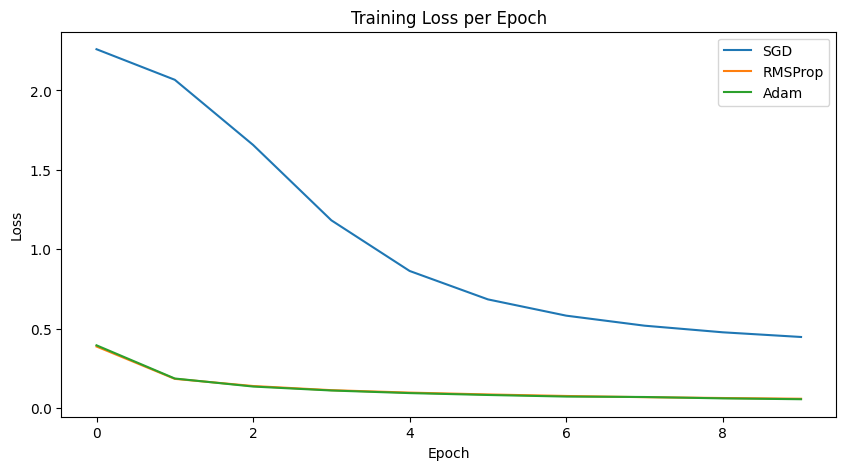

In [23]:
plt.figure(figsize=(10,5))
plt.plot(sgd_loss, label='SGD')
plt.plot(rms_loss, label='RMSProp')
plt.plot(adam_loss, label='Adam')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### To make the RMSProp line more visible for clarity

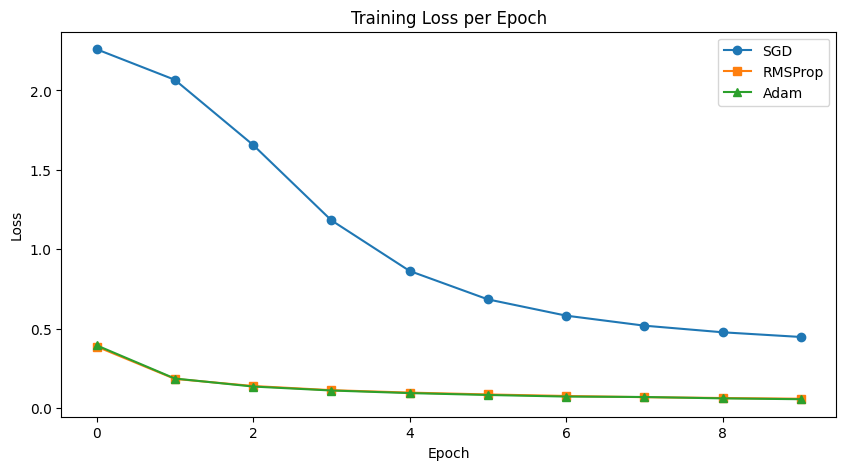

In [31]:
plt.figure(figsize=(10,5))
plt.plot(sgd_loss, label='SGD', marker='o')
plt.plot(rms_loss, label='RMSProp', marker='s')
plt.plot(adam_loss, label='Adam', marker='^')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**SGD** converges slowly because it uses a fixed learning rate and does not adapt per parameter. **RMSProp** converges faster due to adaptive learning rates that scale updates according to past gradient magnitudes. **Adam** converges fastest and lowest due to combining momentum and adaptive learning rates, which stabilizes training and reduces loss efficiently.

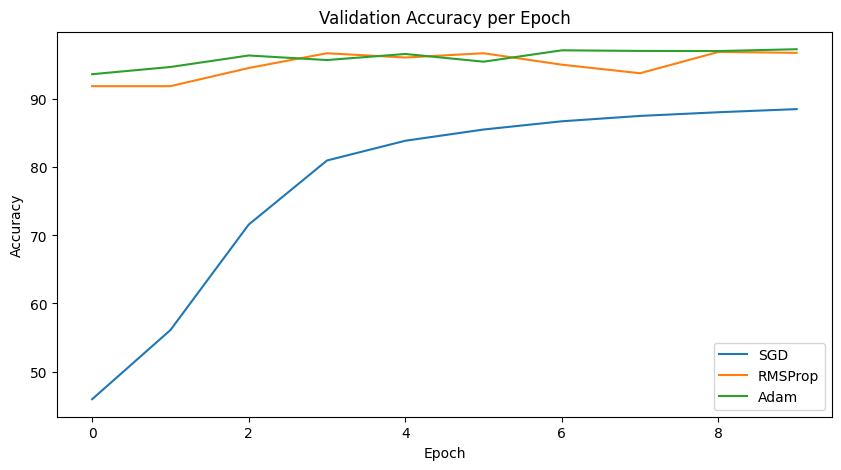

In [26]:
plt.figure(figsize=(10,5))
plt.plot(sgd_acc, label='SGD')
plt.plot(rms_acc, label='RMSProp')
plt.plot(adam_acc, label='Adam')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**SGD** is slower and requires more epochs to reach competitive accuracy. **RMSProp** improves accuracy rapidly but shows slight fluctuations, likely due to the adaptive nature of its updates. **Adam** is both fast and smooth, achieving slightly higher accuracy than RMSProp because momentum helps it maintain consistent direction while adaptive learning rates speed up training.

### Interpretation

The choice of optimizer depends on achieving high validation accuracy with low training loss and fast convergence.

**1. Convergence Speed (Accuracy)**
Adam and RMSProp converge quickly to a high validation accuracy (above 90%) within the first few epochs (around Epoch 3).

SGD is significantly slower, only reaching 88.56% validation accuracy by the end of Epoch 10.

**2. Final Performance (Epoch 10)**
| Optimizer | Final Training Loss | Final Validation Accuracy |
|---|---|---|
| SGD | 0.4489 | 88.56% |
| RMSProp | 0.0604 | 96.83% |
| Adam | 0.0573 | 97.36% |

* Adam achieves the highest final validation accuracy (97.36%) and the lowest final training loss (0.0573), indicating the best performance overall.
* RMSProp is very close but slightly underperforms Adam.
* SGD lags far behind both adaptive methods.

**3. Stability**
* Adam and RMSProp are significantly more effective at reducing loss than SGD, as seen in the "Training Loss per Epoch" graph, where their lines drop quickly and stay very low.
* While Adam and RMSProp show some fluctuation in validation accuracy (especially RMSProp between Epoch 6 and 8), Adam maintains a consistently high accuracy, eventually peaking highest.

### The Best Optimizer

>**Adam** gets you learning fast and accurate. **RMSProp** gets you learning fast but sometimes unstable. **SGD** gets you learning slow but sometimes right.